# Линейная регрессия и регуляризация

Построим воспроизводимый baseline для прогноза числового показателя. Проведём первичный анализ данных, обучим Ridge Regression, оценим качество и разберём остатки и коэффициенты модели.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

Matplotlib is building the font cache; this may take a moment.


## Данные

In [2]:
dataset = load_diabetes(as_frame=True)
data = dataset.frame.rename(columns={"target": "disease_progression"})

display(data.head())
display(data.describe().T)
print("Размер:", data.shape)
print("Пропуски:", int(data.isna().sum().sum()))

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,disease_progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.293722e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


Размер: (442, 11)
Пропуски: 0


## Распределение целевой переменной и корреляции

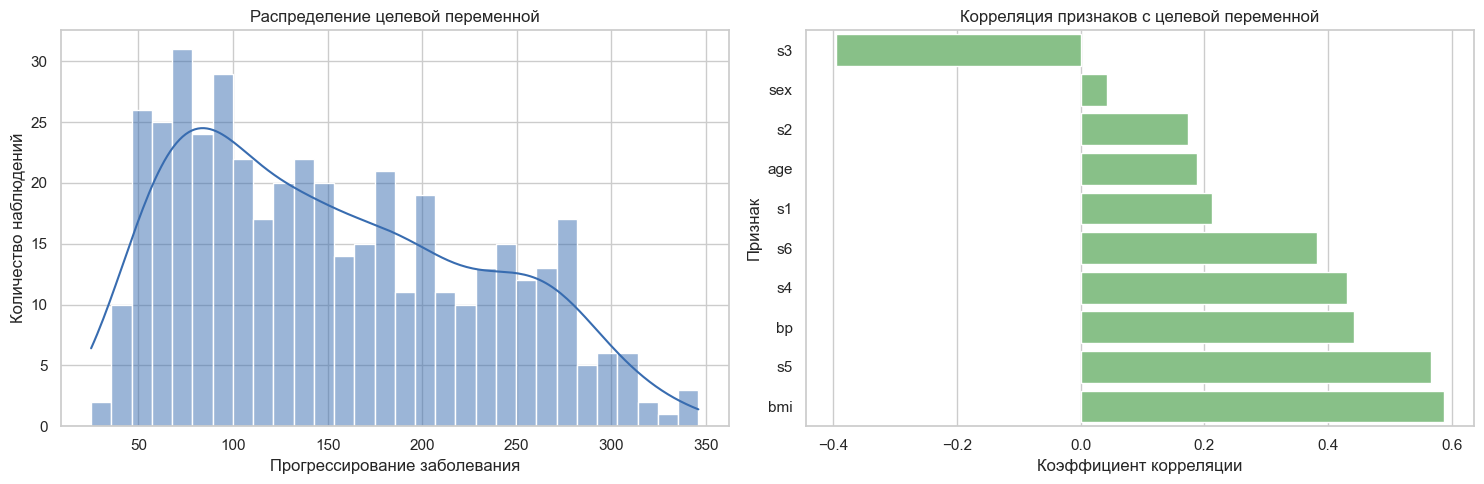

In [3]:
correlations = data.corr(numeric_only=True)["disease_progression"].drop("disease_progression").sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(data["disease_progression"], bins=30, kde=True, ax=axes[0], color="#386cb0")
axes[0].set_title("Распределение целевой переменной")
axes[0].set_xlabel("Прогрессирование заболевания")
axes[0].set_ylabel("Количество наблюдений")

sns.barplot(x=correlations.values, y=correlations.index, ax=axes[1], color="#7fc97f")
axes[1].set_title("Корреляция признаков с целевой переменной")
axes[1].set_xlabel("Коэффициент корреляции")
axes[1].set_ylabel("Признак")
plt.tight_layout()
plt.show()

## Обучение модели

In [4]:
features = data.drop(columns="disease_progression")
target = data["disease_progression"]
train_features, test_features, train_target, test_target = train_test_split(
    features, target, test_size=0.2, random_state=42
)

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", RidgeCV(alphas=np.logspace(-3, 3, 31))),
])
pipeline.fit(train_features, train_target)
prediction = pipeline.predict(test_features)

## Метрики

In [5]:
metrics = pd.DataFrame({
    "metric": ["MAE", "RMSE", "R2", "selected alpha"],
    "value": [
        mean_absolute_error(test_target, prediction),
        np.sqrt(mean_squared_error(test_target, prediction)),
        r2_score(test_target, prediction),
        pipeline.named_steps["model"].alpha_,
    ],
})
metrics

,metric,value
0,MAE,42.811999
1,RMSE,53.777454
2,R2,0.454147
3,selected alpha,1.000000


## Предсказания и остатки

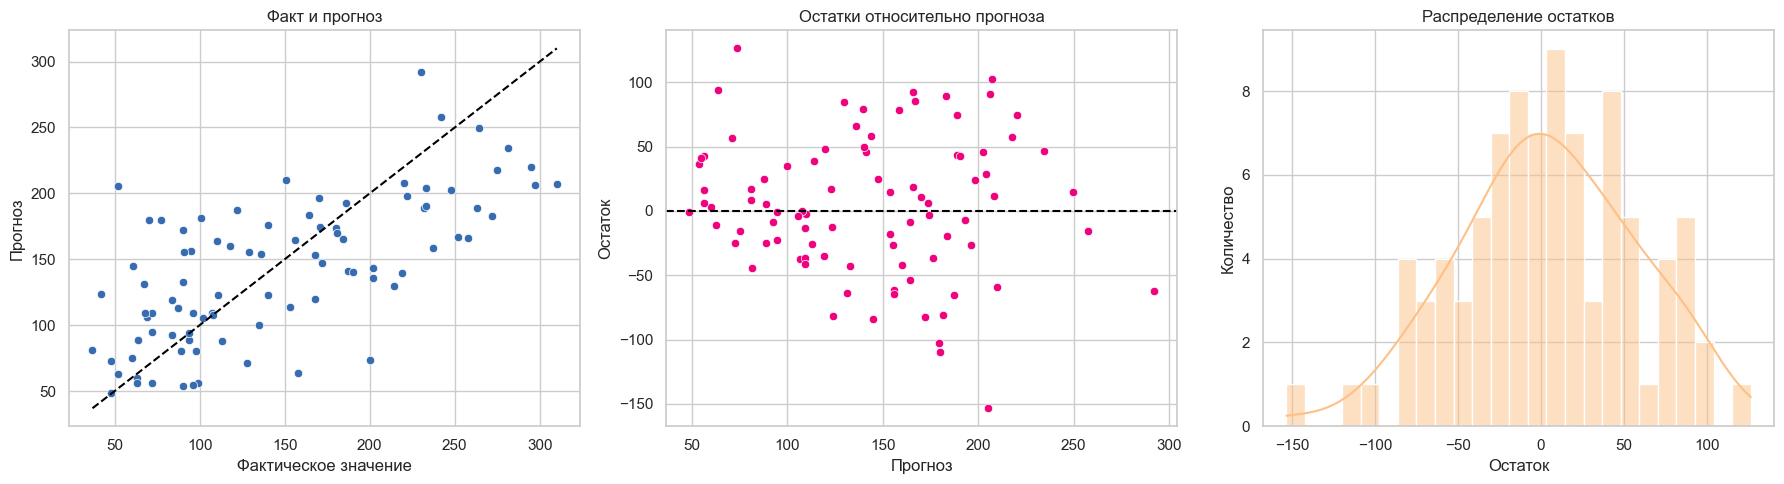

In [6]:
residuals = test_target - prediction
limits = [min(test_target.min(), prediction.min()), max(test_target.max(), prediction.max())]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(x=test_target, y=prediction, ax=axes[0], color="#386cb0")
axes[0].plot(limits, limits, linestyle="--", color="black")
axes[0].set_title("Факт и прогноз")
axes[0].set_xlabel("Фактическое значение")
axes[0].set_ylabel("Прогноз")

sns.scatterplot(x=prediction, y=residuals, ax=axes[1], color="#f0027f")
axes[1].axhline(0, linestyle="--", color="black")
axes[1].set_title("Остатки относительно прогноза")
axes[1].set_xlabel("Прогноз")
axes[1].set_ylabel("Остаток")

sns.histplot(residuals, bins=25, kde=True, ax=axes[2], color="#fdc086")
axes[2].set_title("Распределение остатков")
axes[2].set_xlabel("Остаток")
axes[2].set_ylabel("Количество")
plt.tight_layout()
plt.show()

## Коэффициенты модели

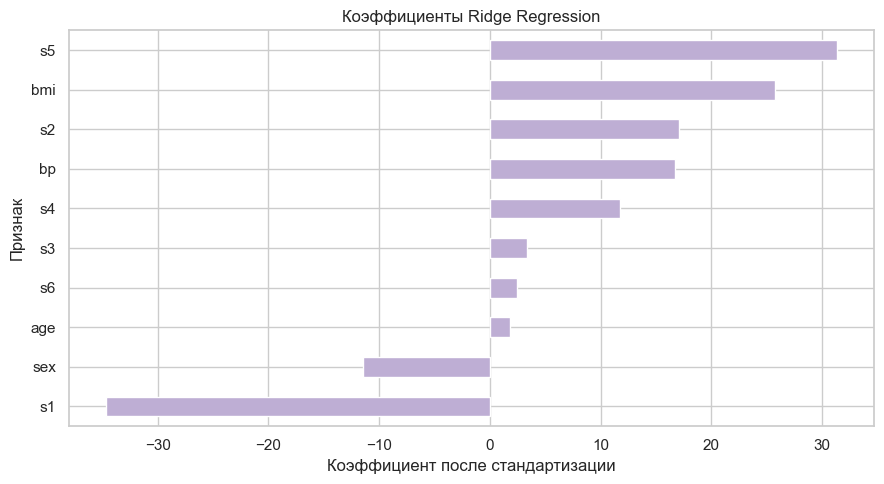

In [7]:
coefficients = pd.Series(
    pipeline.named_steps["model"].coef_,
    index=features.columns,
).sort_values()

coefficients.plot.barh(figsize=(9, 5), color="#beaed4")
plt.title("Коэффициенты Ridge Regression")
plt.xlabel("Коэффициент после стандартизации")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

## Вывод

Регуляризация ограничивает величину коэффициентов и делает линейную модель устойчивее. График «факт — прогноз» показывает общую точность, а анализ остатков помогает заметить систематические ошибки и выбросы.

## Расширенный анализ качества модели

Сравним Ridge Regression с простым baseline, исследуем устойчивость регуляризации, построим learning curve и оценим неопределённость коэффициентов.

In [8]:
from scipy import stats
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score, learning_curve

In [9]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(train_features, train_target)
baseline_prediction = baseline.predict(test_features)

baseline_comparison = pd.DataFrame({
    "model": ["Mean baseline", "RidgeCV"],
    "MAE": [
        mean_absolute_error(test_target, baseline_prediction),
        mean_absolute_error(test_target, prediction),
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(test_target, baseline_prediction)),
        np.sqrt(mean_squared_error(test_target, prediction)),
    ],
    "R2": [
        r2_score(test_target, baseline_prediction),
        r2_score(test_target, prediction),
    ],
})
baseline_comparison

,model,MAE,RMSE,R2
0,Mean baseline,64.006461,73.222493,-0.011963
1,RidgeCV,42.811999,53.777454,0.454147


### Корреляционная структура признаков

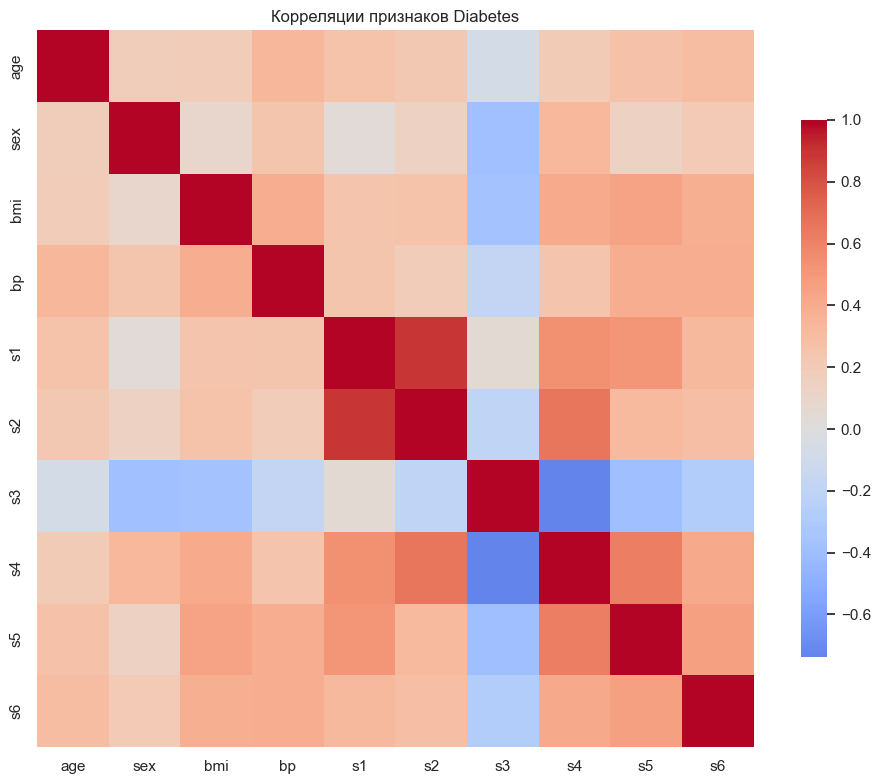

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(features.corr(), cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.75})
plt.title("Корреляции признаков Diabetes")
plt.tight_layout()
plt.show()

### Устойчивость коэффициента регуляризации

,value
alpha,0.316228
rmse_mean,54.914321
rmse_std,3.449211


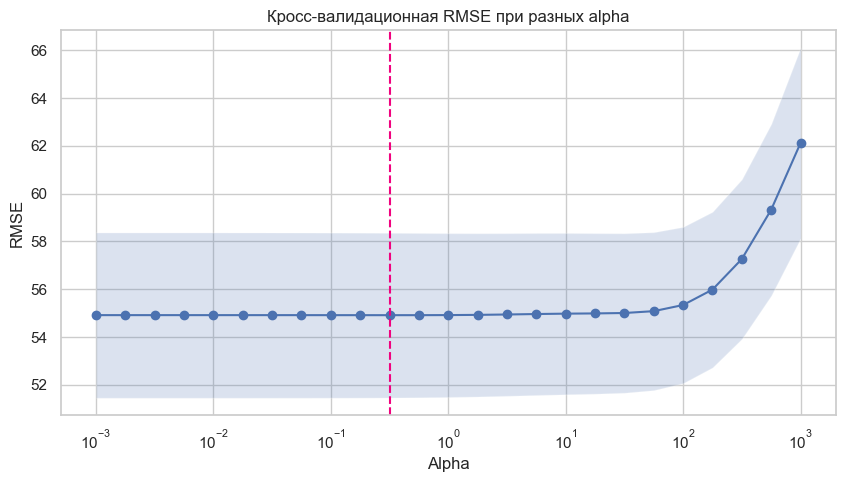

In [11]:
validation = KFold(n_splits=7, shuffle=True, random_state=42)
alpha_rows = []
for alpha in np.logspace(-3, 3, 25):
    candidate = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=alpha)),
    ])
    scores = -cross_val_score(
        candidate,
        features,
        target,
        scoring="neg_root_mean_squared_error",
        cv=validation,
    )
    alpha_rows.append({"alpha": alpha, "rmse_mean": scores.mean(), "rmse_std": scores.std()})

alpha_results = pd.DataFrame(alpha_rows)
best_alpha_row = alpha_results.loc[alpha_results["rmse_mean"].idxmin()]
display(best_alpha_row.to_frame("value"))

plt.figure(figsize=(10, 5))
plt.semilogx(alpha_results["alpha"], alpha_results["rmse_mean"], marker="o")
plt.fill_between(
    alpha_results["alpha"],
    alpha_results["rmse_mean"] - alpha_results["rmse_std"],
    alpha_results["rmse_mean"] + alpha_results["rmse_std"],
    alpha=0.2,
)
plt.axvline(best_alpha_row["alpha"], linestyle="--", color="#f0027f")
plt.title("Кросс-валидационная RMSE при разных alpha")
plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.show()

### Learning curve

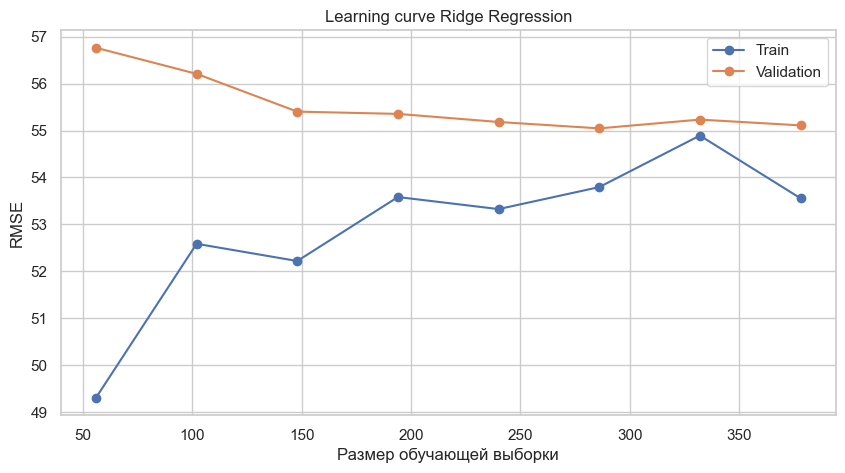

In [12]:
train_sizes, train_scores, validation_scores = learning_curve(
    pipeline,
    features,
    target,
    cv=validation,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.15, 1.0, 8),
)

learning_frame = pd.DataFrame({
    "train_size": train_sizes,
    "train_rmse": -train_scores.mean(axis=1),
    "validation_rmse": -validation_scores.mean(axis=1),
})

plt.figure(figsize=(10, 5))
plt.plot(learning_frame["train_size"], learning_frame["train_rmse"], marker="o", label="Train")
plt.plot(learning_frame["train_size"], learning_frame["validation_rmse"], marker="o", label="Validation")
plt.title("Learning curve Ridge Regression")
plt.xlabel("Размер обучающей выборки")
plt.ylabel("RMSE")
plt.legend()
plt.show()

### Нормальность и стабильность остатков

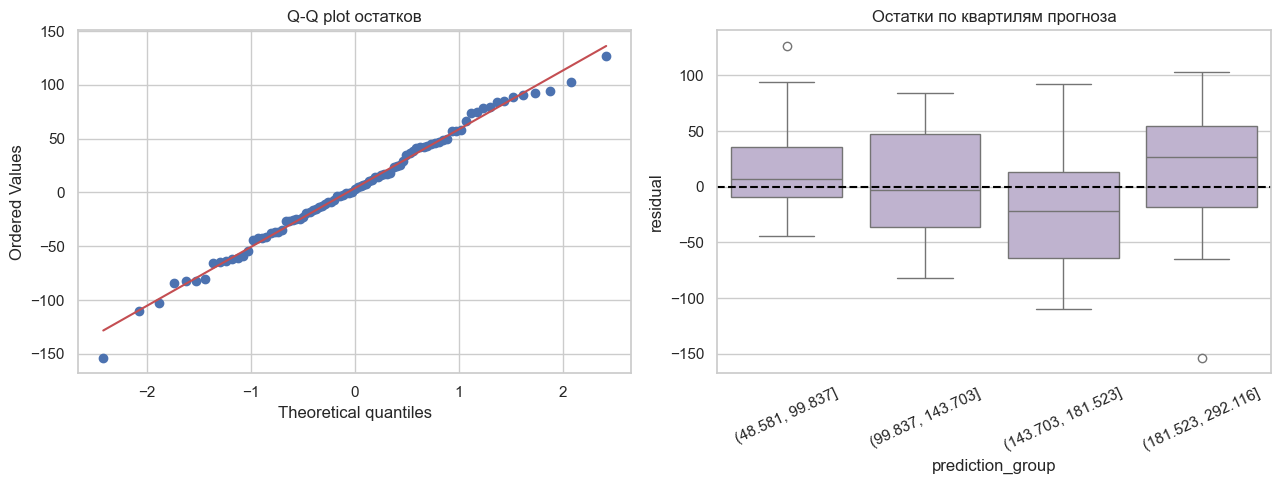

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
stats.probplot(residuals, dist="norm", plot=axes[0])
axes[0].set_title("Q-Q plot остатков")

residual_frame = pd.DataFrame({"prediction": prediction, "residual": residuals})
residual_frame["prediction_group"] = pd.qcut(residual_frame["prediction"], q=4, duplicates="drop")
sns.boxplot(data=residual_frame, x="prediction_group", y="residual", ax=axes[1], color="#beaed4")
axes[1].axhline(0, linestyle="--", color="black")
axes[1].set_title("Остатки по квартилям прогноза")
axes[1].tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

### Bootstrap-интервалы коэффициентов

In [14]:
bootstrap_coefficients = []
rng = np.random.default_rng(42)
for _ in range(200):
    sample_indices = rng.integers(0, len(train_features), len(train_features))
    sample_features = train_features.iloc[sample_indices]
    sample_target = train_target.iloc[sample_indices]
    bootstrap_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=pipeline.named_steps["model"].alpha_)),
    ])
    bootstrap_model.fit(sample_features, sample_target)
    bootstrap_coefficients.append(bootstrap_model.named_steps["model"].coef_)

bootstrap_frame = pd.DataFrame(bootstrap_coefficients, columns=features.columns)
coefficient_intervals = pd.DataFrame({
    "mean": bootstrap_frame.mean(),
    "lower_95": bootstrap_frame.quantile(0.025),
    "upper_95": bootstrap_frame.quantile(0.975),
}).sort_values("mean")
coefficient_intervals

,mean,lower_95,upper_95
s1,-32.790862,-64.577181,-0.170197
sex,-11.515079,-17.877142,-5.287312
age,1.797775,-4.159408,7.828002
s6,2.346205,-5.364824,10.070885
s3,3.098313,-14.563602,20.056347
s4,12.622996,-2.742956,27.655440
s2,14.970071,-9.912357,37.842469
bp,16.745930,9.690644,23.482258
bmi,25.492816,18.750754,33.508128
s5,30.773004,16.958672,43.633137


### Итог расширенного анализа

Сравнение с baseline показывает реальную добавленную ценность модели. Кросс-валидация проверяет устойчивость alpha, learning curve разделяет дефицит данных и ограничения модели, а bootstrap-интервалы показывают, какие коэффициенты сохраняют направление при изменении обучающей выборки.